## Connect to database

In [14]:
cd ..

/


In [ ]:
%run run.py connect

## Base imports

In [42]:
from vr4mice.analysis.summary_dj import fetch_data
from vr4mice.analysis.analysis import style
import matplotlib.pyplot as plt
import vr4mice.analysis.plotting as plotting

## Pass arguments

In [ ]:
# def vr4mice_summary_plots(
#    key: Dict, save_path: str = "/data/summary_plots", database: bool = True
# ):
key =  {"dataset": "Jacana_2024-08-21_1"} # Random mouse dataset for demo
save_path = "/data/summary_plots"
database = True

style()

## Fetch while huge dataset for 1 key

In [38]:
import time
start_time = time.time()
df, box_df_output = fetch_data(key, database=True)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

2024-10-11 14:49:15,925::INFO::summary_dj.py::Trying to get data from database...
2024-10-11 14:50:48,633::INFO::summary_dj.py::Data fetched for {'dataset': 'Jacana_2024-08-21_1'}
2024-10-11 14:50:48,634::INFO::summary_dj.py::Add trial rewarded...
2024-10-11 14:50:55,963::INFO::summary_dj.py::Box data fetched for {'dataset': 'Jacana_2024-08-21_1'}


Elapsed time: 100.0406 seconds


In [43]:
# identical to prev, but without timer
# df, box_df_output = fetch_data(key, database)

## Some steps that needs comments from Tom and Celia
Note(mary): @tom why copy? why we sort iti == 0 here, and not during the fetch from database?... \
=> (fetch only session that are under certain condition, this is a good practice!)

In [151]:
df = df[df.iti == 0]

 # NOTE: so that the head_dir is align to the screen
df["head_dir"] = ((df.head_dir) + 180) % 360 - 180

num_apertures = len(df.aperture.unique())

## Create the summary figure grid (no inteterst to run here)
Note(mary)=> TODO: this has to be a separate function! \
and the attribution of axes may be automatic... (via indexing)

In [ ]:


fig = plt.figure(figsize=(25, 20), constrained_layout=True)
gs = plt.GridSpec(6, 10, figure=fig)

ax1 = fig.add_subplot(gs[0:2, 0:3])
ax2 = fig.add_subplot(gs[0:2, 3:5])
ax3 = fig.add_subplot(gs[0:2, 5:7])
ax10 = fig.add_subplot(gs[0:2, 7:10])

ax5 = fig.add_subplot(gs[2, 0:2])
ax6 = fig.add_subplot(gs[2, 2:4])
time_plots_aperture = fig.add_subplot(gs[2, 4:6])
time_plots_reward = fig.add_subplot(gs[2, 6:8])
time_plots_choice = fig.add_subplot(gs[2, 8:10])

velocity_plot_aperture = fig.add_subplot(gs[3, 0:2])
velocity_plot_reward = fig.add_subplot(gs[3, 2:4])
velocity_plot_choice = fig.add_subplot(gs[3, 4:6])
heading_angle_plot = fig.add_subplot(gs[3, 6:8])
j_shaped_plot = fig.add_subplot(gs[3, 8:10])

ax7 = fig.add_subplot(gs[4, 0:2])
ax8 = fig.add_subplot(gs[4, 2:])
ax4 = fig.add_subplot(gs[5, 0:2])
ax9 = fig.add_subplot(gs[5, 2:])


## Display all trials

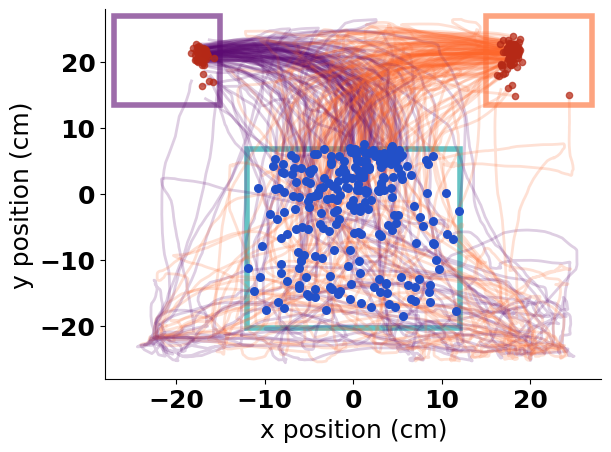

In [152]:
fig, ax1 = plt.subplots()

plotting.plot_session(
    df=df,
    box_df=box_df_output,
    per_aperture=False,
    per_side=True,
    ax=ax1,
)

plt.show()

## Display all rewarded trials on left side

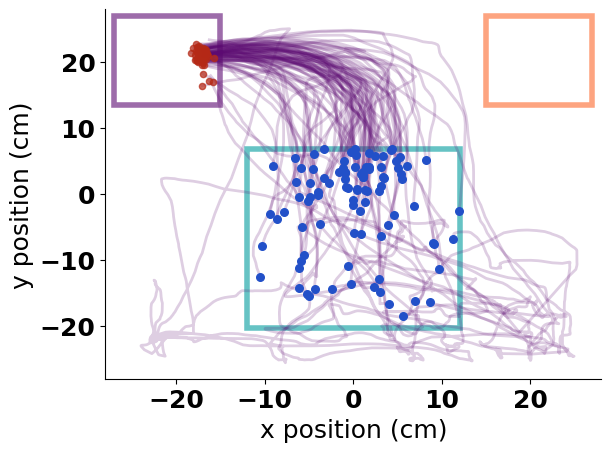

In [143]:
fig, ax2 = plt.subplots()

plotting.plot_session(
    df=df[(df.trial_rewarded == 1) & (df.trial_left_choice == 1)],
    box_df=box_df_output,
    per_aperture=False,
    per_side=True,
    ax=ax2,
)
plt.show()

## Display all rewarded trials on right side

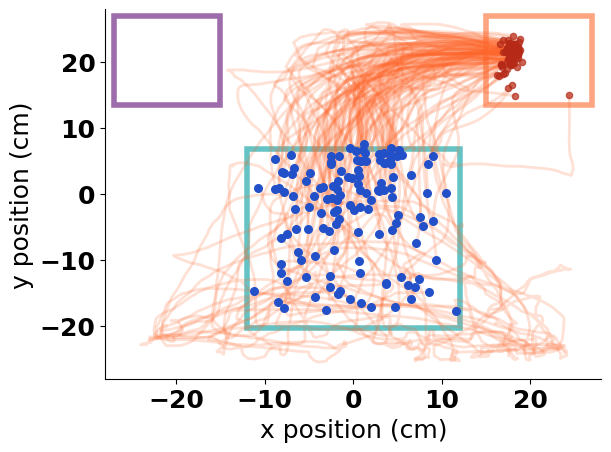

In [133]:
fig, ax3 = plt.subplots()
plotting.plot_session(
     df=df[(df.trial_rewarded == 1) & (df.trial_right_choice == 1)],
     box_df=box_df_output,
     per_aperture=False,
     per_side=True,
     ax=ax3,
)
plt.show()

 ## Display mean trajectory for the j-shaped trials
Note(mary): fetch it from database, don't calculate \
Note(mary)-2: Tom you mentioned we don't want this JShaped table, which one, tho?

In [50]:
j_shaped_df = base_analysis.JShaped().get_jshaped(key) # database solution

In [145]:
# apparently for future steps y variable also needed, but it's not in the JShaped() but can be always fetched from somewhere else!

# example with huge dataset (that we already fetched earlier via fetch_data)
# j_shaped_df['y'] = df['y']

# example how it may be done once you are working with database! (or via fetch and join)
ret = base_analysis.DataFrame().get_data(key=key, columns=['y', 'x', 'aperture', 'choice'])
j_shaped_df[['y', 'x', 'aperture', 'choice']] = ret[['y', 'x', 'aperture', 'choice']]

In [136]:
from vr4mice.analysis import utils
j_shaped_df = utils.create_bins(
        data=j_shaped_df, spatial_ybins=[6.75, 20, 25], label="y"
)

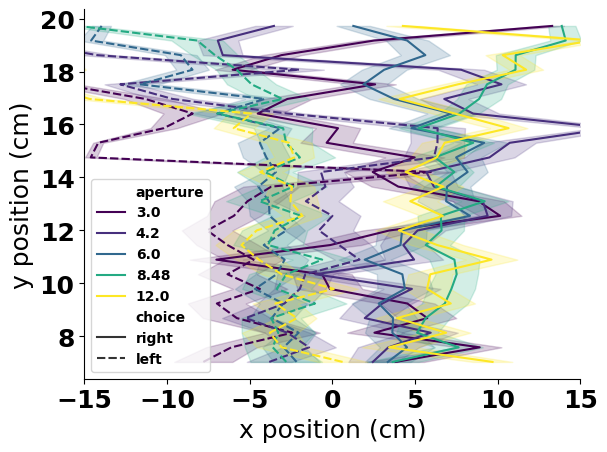

In [144]:
fig, ax10 = plt.subplots()
plotting.lineplot_flip_axis(
        data=j_shaped_df_db,
        x="bin_centers",
        y="x",
        hue="choice" if num_apertures <= 2 else "aperture",
        palette=plotting.colors_choice if num_apertures <= 2 else "viridis",
        style="aperture" if num_apertures <= 2 else "choice",
        errorbar="se",
        ax=ax10,
)

ax10.set_xlim([-15, 15])
ax10.set_ylabel("y position (cm)")
ax10.set_xlabel("x position (cm)")

plt.show()

## Display the choice rate
Note(mary): hide runtime warnings or fix them?

2024-10-11 15:58:25,428::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:58:25,436::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
2024-10-11 15:58:25,463::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

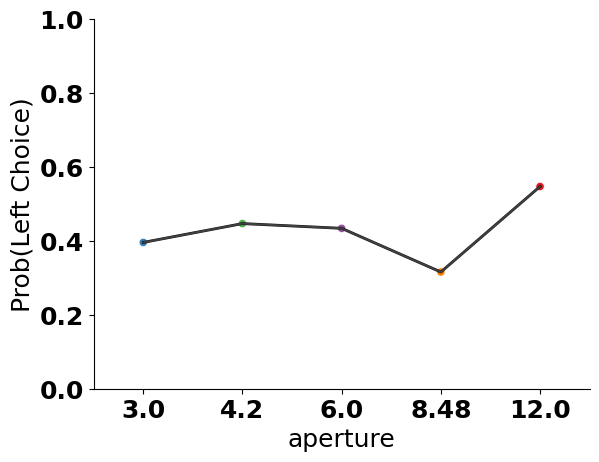

In [138]:
fig, ax4 = plt.subplots()

plotting.plot_rate(
        df=df,
        label_x="trial_left_choice",
        per_aperture=True if num_apertures >= 2 else False,
        ax=ax4,
)
ax4.set_ylabel("Prob(Left Choice)")
ax4.set_ylim([0, 1])
plt.show()

## Display the target location rate
Note(mary) Tom it's still empty, even if we switch columns...

2024-10-11 15:58:28,539::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:58:28,546::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:58:28,571::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:58:28,577::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:58:28,595::INFO::category.py::Using categorical un

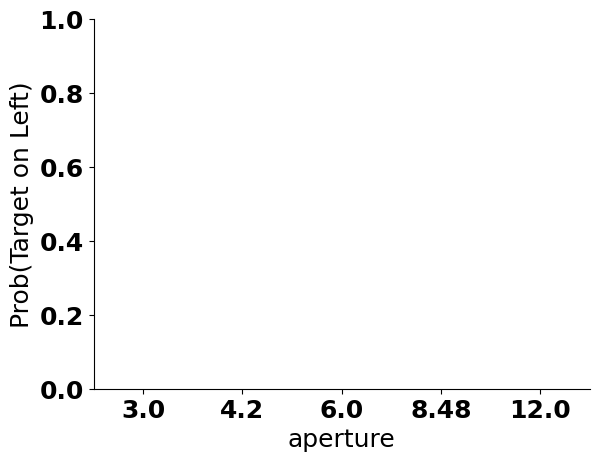

In [139]:
fig, ax5 = plt.subplots()
plotting.plot_rate(
        df=df,
        label_x="object_on_left",
        per_aperture=True if num_apertures >= 2 else False,
        ax=ax5,
    )
ax5.set_ylabel("Prob(Target on Left)")
ax5.set_ylim([0, 1])
plt.show()

## Display trial count
Note(mary): hide runtime warnings or fix them?

2024-10-11 15:29:17,869::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:29:17,876::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
2024-10-11 15:29:17,907::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

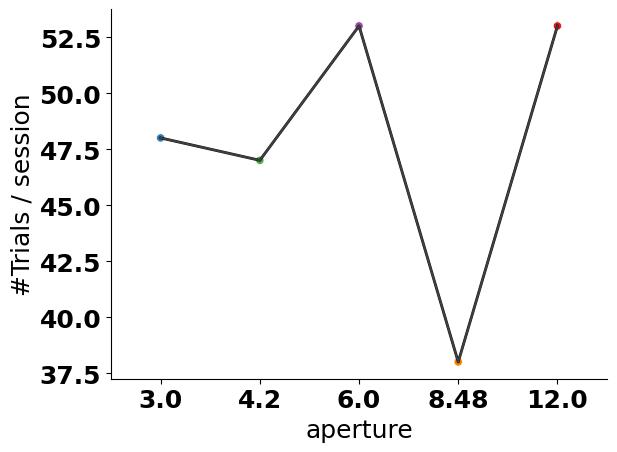

In [105]:
fig, ax6 = plt.subplots()
plotting.plot_trial_count(
        df=df,
        per_aperture=True if num_apertures >= 2 else False,
        ax=ax6,
    )
plt.show()

## Display the reward rate

2024-10-11 15:30:54,001::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:30:54,006::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
2024-10-11 15:30:54,033::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

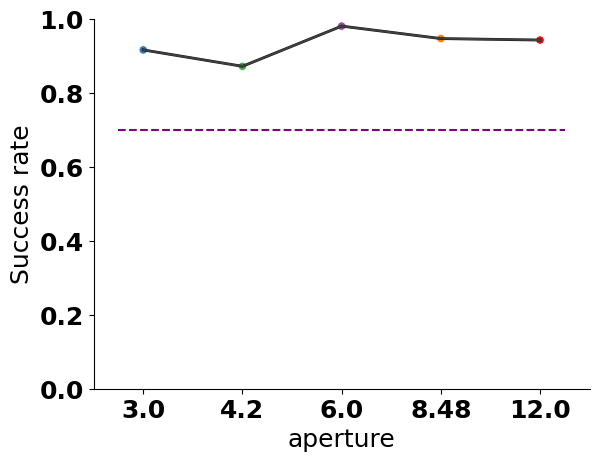

In [108]:
fig, ax7 = plt.subplots()
plotting.plot_rewards(
        df=df, per_aperture=True if num_apertures >= 2 else False, ax=ax7
    )
plt.show()

## Display the time to reward 


### per aperture

2024-10-11 15:33:19,604::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:33:19,609::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
2024-10-11 15:33:19,633::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

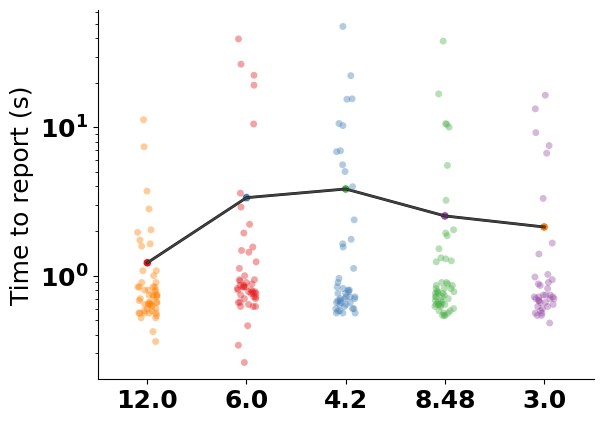

In [111]:
fig, ax = plt.subplots()

plotting.plot_time_to_reward(
        df,
        label_x="aperture",
        xticks=list(df.aperture.unique()),
        ax=ax #time_plots_aperture,
)

plt.show()

### per trial rewarded

2024-10-11 15:34:05,134::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:34:05,146::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
2024-10-11 15:34:05,172::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

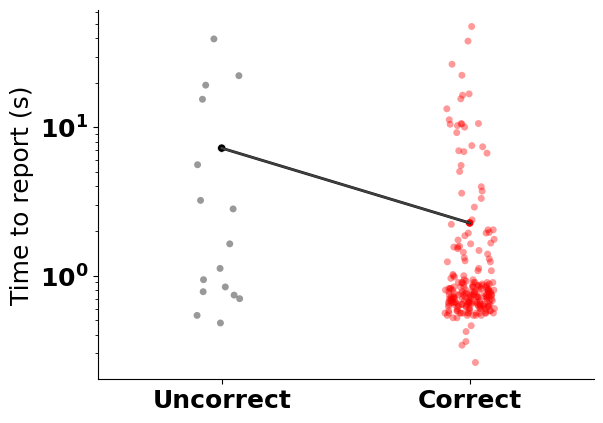

In [112]:
fig, ax = plt.subplots()

plotting.plot_time_to_reward(
        df,
        label_x="trial_rewarded",
        xticks=["Uncorrect", "Correct"],
        ax=ax#time_plots_reward,
)
plt.show()

###  per choice


2024-10-11 15:35:21,925::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:35:21,930::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
2024-10-11 15:35:21,963::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

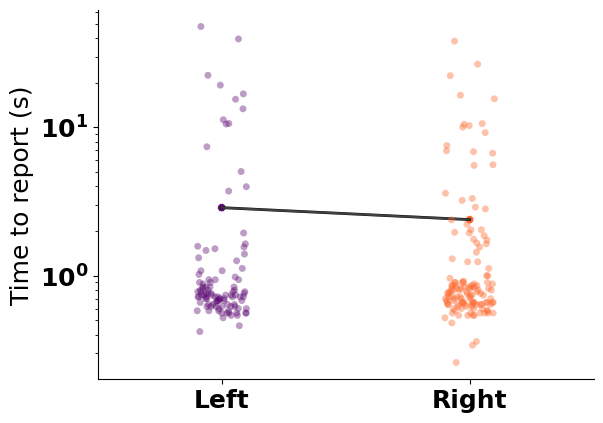

In [114]:
fig, ax = plt.subplots()

plotting.plot_time_to_reward(
        df, label_x="trial_right_choice", xticks=["Left", "Right"], ax=ax #time_plots_choice
)

plt.show()

## Interpolation on variable of interest
Note(mary): why it happens here? It's ummary plots... we should plot only here... or create the aditional func

In [146]:
columns = [
        "y",
        "head_dir",
        "trial_tortuosity",
        "trial_duration",
        "x",
        "aperture",
        "velocity",
        "velocity_x",
        "velocity_y",
        "trial_traj_path_length",
        "flip_one_side",
    ]

interpolated_df = utils.interpolate(
        df,
        n_points=200,
        value_columns=["trial_left_choice", "trial_right_choice", "trial_rewarded"]
        + columns,
)

interpolated_df["trial_step"] = interpolated_df.groupby(
        ["dataset", "trial"]
).trial.cumcount()
interpolated_df["trial_length"] = interpolated_df["trial_step"] / 200

## Display the speed

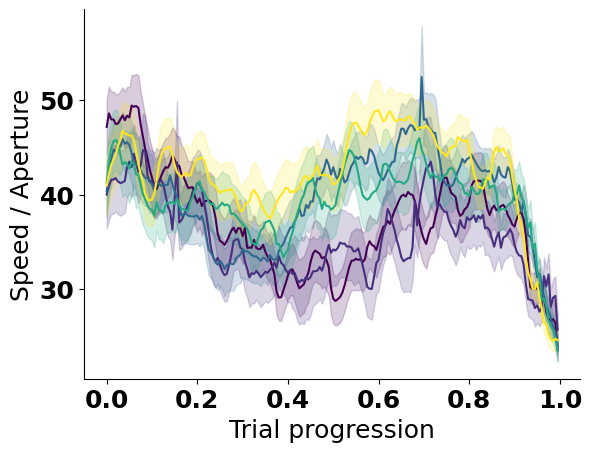

In [147]:
import seaborn as sns

fig, velocity_plot_aperture = plt.subplots()
sns.lineplot(
        data=interpolated_df,
        x="trial_length",
        y="velocity",
        palette=(plotting.colors_aperture[:2] if num_apertures == 2 else "viridis"),
        hue="aperture",
        errorbar="se",
        ax=velocity_plot_aperture,
    )
velocity_plot_aperture.legend([], [], frameon=False)
velocity_plot_aperture.set_ylabel("Speed / Aperture")
velocity_plot_aperture.set_xlabel("Trial progression")

plt.show()

## per trial rewarded

Text(0.5, 0, 'Trial progression')

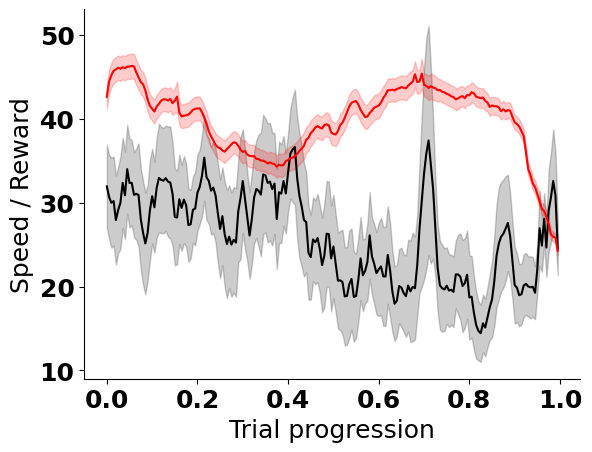

In [148]:
import seaborn as sns

fig, velocity_plot_reward = plt.subplots()
sns.lineplot(
        data=interpolated_df,
        x="trial_length",
        y="velocity",
        palette=plotting.colors_rewarded,
        hue="trial_rewarded",
        errorbar="se",
        ax=velocity_plot_reward,
)
velocity_plot_reward.legend([], [], frameon=False)
velocity_plot_reward.set_ylabel("Speed / Reward")
velocity_plot_reward.set_xlabel("Trial progression")

## per choice

Text(0.5, 0, 'Trial progression')

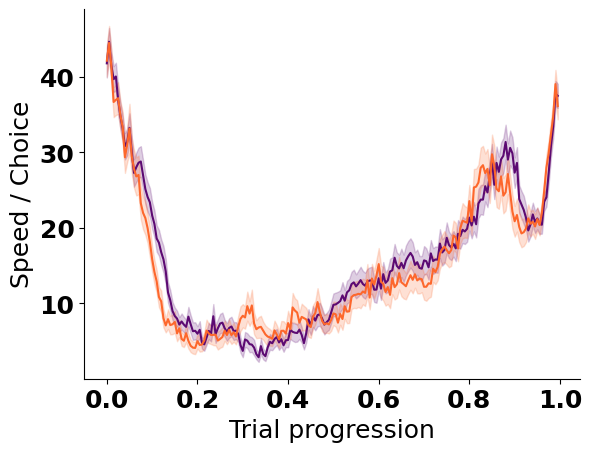

In [141]:
import seaborn as sns

fig, velocity_plot_choice = plt.subplots()

sns.lineplot(
        data=interpolated_df,
        x="trial_length",
        y="velocity",
        palette=plotting.colors_choice,
        hue="trial_left_choice",
        errorbar="se",
        ax=velocity_plot_choice,
    )
velocity_plot_choice.legend([], [], frameon=False)
velocity_plot_choice.set_ylabel("Speed / Choice")
velocity_plot_choice.set_xlabel("Trial progression")

## Display heading direction per choice

Text(0.5, 0, 'Trial progression')

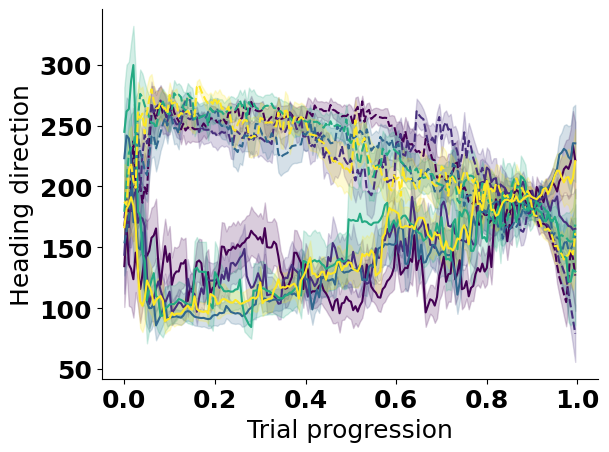

In [128]:
import seaborn as sns

fig, heading_angle_plot = plt.subplots()

sns.lineplot(
        data=interpolated_df,
        x="trial_length",
        y="head_dir",
        hue="trial_right_choice" if num_apertures <= 2 else "aperture",
        palette=plotting.colors_choice if num_apertures <= 2 else "viridis",
        style="aperture" if num_apertures <= 2 else "trial_right_choice",
        errorbar="se",
        ax=heading_angle_plot,
    )
heading_angle_plot.legend([], [], frameon=False)
heading_angle_plot.set_ylabel("Heading direction")
heading_angle_plot.set_xlabel("Trial progression")


## Display J-shaped trials rate

2024-10-11 15:42:52,212::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-10-11 15:42:52,218::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.9/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
2024-10-11 15:42:52,242::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plot

(0.0, 1.0)

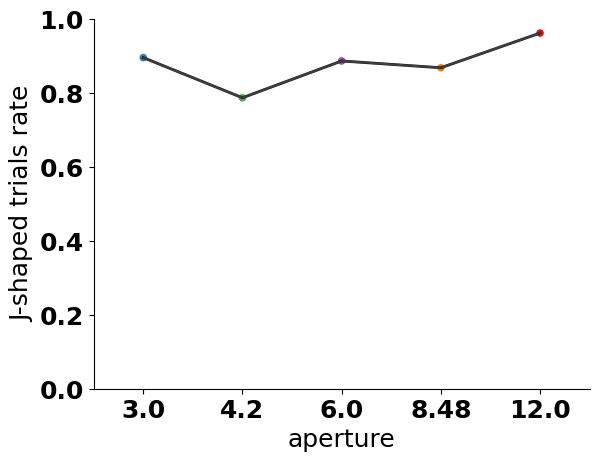

In [129]:
import seaborn as sns

fig, j_shaped_plot = plt.subplots()

plotting.plot_rate(
        df=df,
        label_x="is_j_shaped",
        per_aperture=True if num_apertures >= 2 else False,
        ax=j_shaped_plot,
    )
j_shaped_plot.set_ylabel("J-shaped trials rate")
j_shaped_plot.set_ylim([0, 1])


## Display rolling reward and choice

In [131]:
plotting.plot_rolling_reward(df, ax=ax8)
plotting.plot_choices_by_trial(df, ax=ax9)